In [1]:
# imports
import matplotlib.pyplot as plt
import xarray as xr
from pythia_datasets import DATASETS

In [2]:
#MASKING data
filepath = DATASETS.fetch("CESM2_sst_data.nc")
ds = xr.open_dataset(filepath)
ds

c:\Users\AKHTAR HUSSAIN\anaconda3\envs\climate\Lib\site-packages\xarray\conventions.py:205: SerializationWarning: variable 'tos' has multiple fill values {np.float32(1e+20), np.float64(1e+20)} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)


<xarray.Dataset> Size: 47MB
Dimensions:    (time: 180, d2: 2, lat: 180, lon: 360)
Coordinates:
  * time       (time) object 1kB 2000-01-15 12:00:00 ... 2014-12-15 12:00:00
  * lat        (lat) float64 1kB -89.5 -88.5 -87.5 -86.5 ... 86.5 87.5 88.5 89.5
  * lon        (lon) float64 3kB 0.5 1.5 2.5 3.5 4.5 ... 356.5 357.5 358.5 359.5
Dimensions without coordinates: d2
Data variables:
    time_bnds  (time, d2) object 3kB ...
    lat_bnds   (lat, d2) float64 3kB ...
    lon_bnds   (lon, d2) float64 6kB ...
    tos        (time, lat, lon) float32 47MB ...
Attributes: (12/45)
    Conventions:            CF-1.7 CMIP-6.2
    activity_id:            CMIP
    branch_method:          standard
    branch_time_in_child:   674885.0
    branch_time_in_parent:  219000.0
    case_id:                972
    ...                     ...
    sub_experiment_id:      none
    table_id:               Omon
    tracking_id:            hdl:21.14100/2975ffd3-1d7b-47e3-961a-33f212ea4eb2
    variable_id:            tos
    variant_info:           CMIP6 20th century experiments (1850-2014) with C...
    variant_label:          r11i1p1f1

In [3]:
#Using .where() with One Condition
sample = ds.tos.sel(time="2014-09")
sample

<xarray.DataArray 'tos' (time: 1, lat: 180, lon: 360)> Size: 259kB
[64800 values with dtype=float32]
Coordinates:
  * time     (time) object 8B 2014-09-15 00:00:00
  * lat      (lat) float64 1kB -89.5 -88.5 -87.5 -86.5 ... 86.5 87.5 88.5 89.5
  * lon      (lon) float64 3kB 0.5 1.5 2.5 3.5 4.5 ... 356.5 357.5 358.5 359.5
Attributes: (12/19)
    cell_measures:  area: areacello
    cell_methods:   area: mean where sea time: mean
    comment:        Model data on the 1x1 grid includes values in all cells f...
    description:    This may differ from "surface temperature" in regions of ...
    frequency:      mon
    id:             tos
    ...             ...
    time_label:     time-mean
    time_title:     Temporal mean
    title:          Sea Surface Temperature
    type:           real
    units:          degC
    variable_id:    tos

In [5]:
# mask temperatures greater than or equal to 0, preserve those that are less than 0
masked_sample = sample.where(sample<=0.0)
masked_sample

<xarray.DataArray 'tos' (time: 1, lat: 180, lon: 360)> Size: 259kB
array([[[       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        ...,
        [-1.6132288, -1.6125063, -1.611589 , ..., -1.6145128,
         -1.6141783, -1.6138089],
        [-1.597154 , -1.5969657, -1.5967476, ..., -1.5973103,
         -1.5972834, -1.5972393],
        [-1.5958687, -1.5960269, -1.5961952, ..., -1.5955368,
         -1.5956477, -1.5957516]]], shape=(1, 180, 360), dtype=float32)
Coordinates:
  * time     (time) object 8B 2014-09-15 00:00:00
  * lat      (lat) float64 1kB -89.5 -88.5 -87.5 -86.5 ... 86.5 87.5 88.5 89.5
  * lon      (lon) float64 3kB 0.5 1.5 2.5 3.5 4.5 ... 356.5 357.5 358.5 359.5
Attributes: (12/19)
    cell_measures:  area: areacello
    cell_methods:   area: mean where sea time: mean
    comment:        Model data on the 1x1 grid includes values in all cells f...
    description:    This may differ from "surface temperature" in regions of ...
    frequency:      mon
    id:             tos
    ...             ...
    time_label:     time-mean
    time_title:     Temporal mean
    title:          Sea Surface Temperature
    type:           real
    units:          degC
    variable_id:    tos

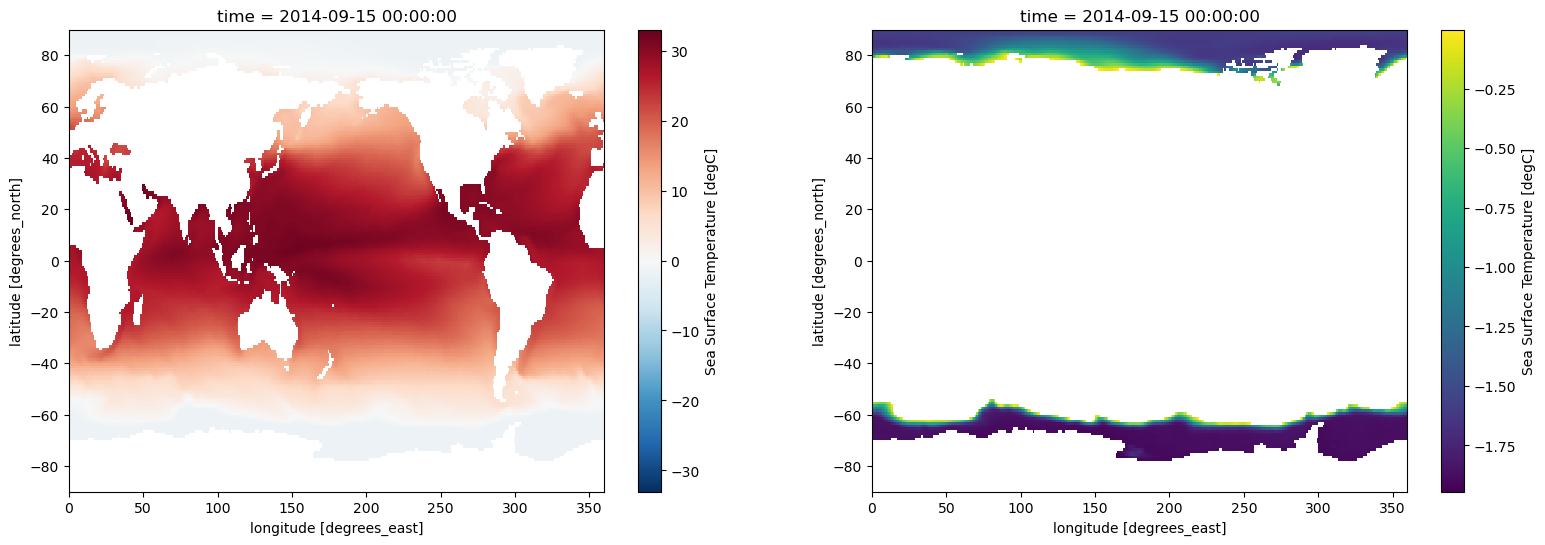

In [8]:
#plot
fig, axes = plt.subplots(ncols=2, figsize=(19, 6))
sample.plot(ax=axes[0])
masked_sample.plot(ax=axes[1])

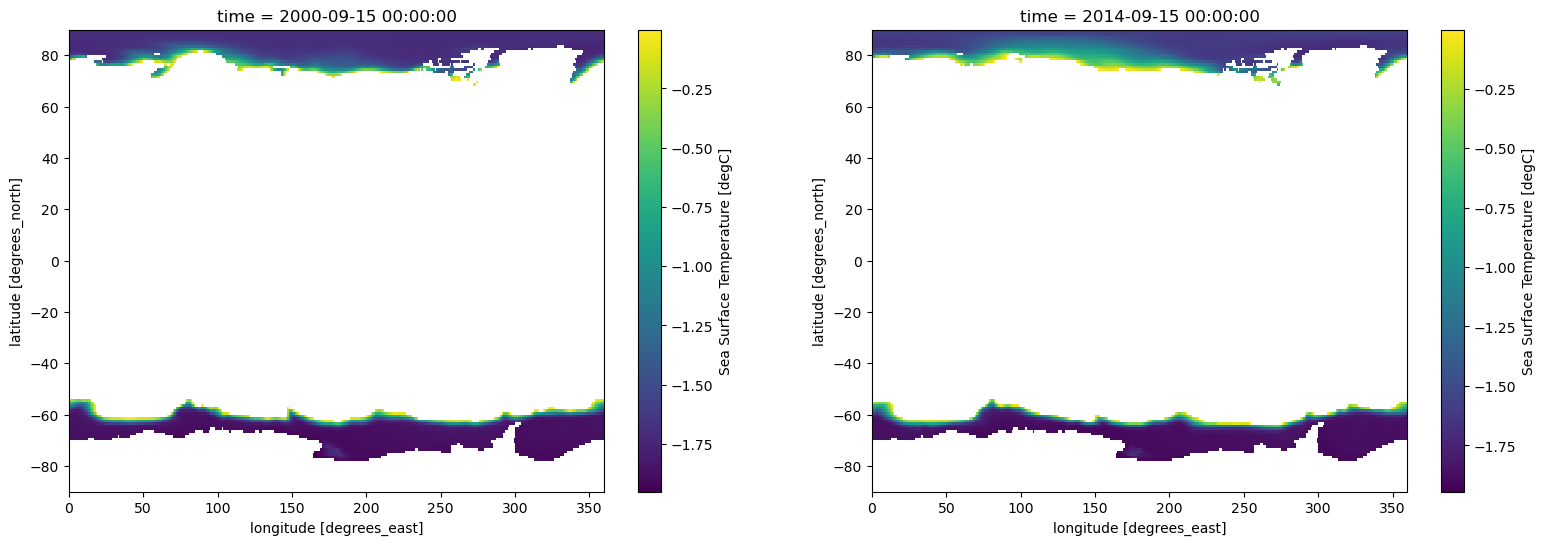

In [10]:
# create a second sample of September 2000
sample_2 = ds.tos.sel(time="2000-09")
# mask it
masked_sample_2 = sample_2.where(sample_2 < 0.0)
# plot both samples next to each other
fig, axes = plt.subplots(ncols=2, figsize=(19, 6))
masked_sample_2.plot(ax=axes[0])
masked_sample.plot(ax=axes[1])